# 03 — Customer Segmentation
### Product Analytics & Experimentation — E-Commerce Funnel

**The story so far:** fulfillment is healthy (97% delivered), but only **3.1%** of customers return,
retention is structurally low across *every* cohort, and the few who come back do so within a median of
**~28 days**.

**This notebook asks: is the retention problem uniform, or does it hide pockets of opportunity?** We slice
the customer base four ways — by **state**, by **first-purchase category**, by **payment method**, and by
**customer value** — to find where repeat behavior and revenue actually concentrate. That tells the next
step (the A/B test) *who* to target.

> Same rule as before: a "customer" is a `customer_unique_id`, and a "repeat customer" is one with more
> than one order.


## 1. Setup

Segmentation needs `products` and the category-name translation, which weren't loaded in earlier sessions. The guard below adds any missing tables from the CSVs.

In [3]:
%pip install duckdb pandas matplotlib seaborn
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("../olist.duckdb")

# Ensure every table this notebook needs is present; load from CSV if missing.
needed = {
    "orders":               "olist_orders_dataset.csv",
    "customers":            "olist_customers_dataset.csv",
    "items":                "olist_order_items_dataset.csv",
    "payments":             "olist_order_payments_dataset.csv",
    "products":             "olist_products_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}
existing = {r[0] for r in con.execute("SHOW TABLES").fetchall()}
for name, file in needed.items():
    if name not in existing:
        con.execute(f"CREATE OR REPLACE TABLE {name} AS "
                    f"SELECT * FROM read_csv_auto('../data/{file}')")

con.execute("SHOW TABLES").df()

Note: you may need to restart the kernel to use updated packages.


,name
0,category_translation
1,customers
2,items
3,orders
4,payments
5,products
6,reviews


## 2. Segment by geography — which states, and do any retain better?

Brazil's e-commerce is concentrated in a few states. We check where customers are, and whether repeat
behavior varies by state (it mostly won't — but confirming that is a finding too).

In [6]:
geo = con.execute('''
    WITH cust AS (
        SELECT
            c.customer_unique_id,
            ANY_VALUE(c.customer_state) AS state,
            COUNT(o.order_id)           AS n_orders
        FROM customers c
        JOIN orders o ON o.customer_id = c.customer_id
        WHERE o.order_purchase_timestamp IS NOT NULL
        GROUP BY c.customer_unique_id
    )
    SELECT
        state,
        COUNT(*)                                                        AS customers,
        ROUND(100.0 * SUM(CASE WHEN n_orders > 1 THEN 1 ELSE 0 END)
              / COUNT(*), 2)                                            AS repeat_rate_pct
    FROM cust
    GROUP BY state
    ORDER BY customers DESC
''').df()
geo.head(12)

,state,customers,repeat_rate_pct
0,SP,40295,3.24
1,RJ,12377,3.41
2,MG,11255,3.06
3,RS,5277,3.20
4,PR,4882,3.05
5,SC,3529,2.72
6,BA,3276,2.87
7,DF,2073,3.04
8,ES,1963,2.90
9,GO,1951,3.33


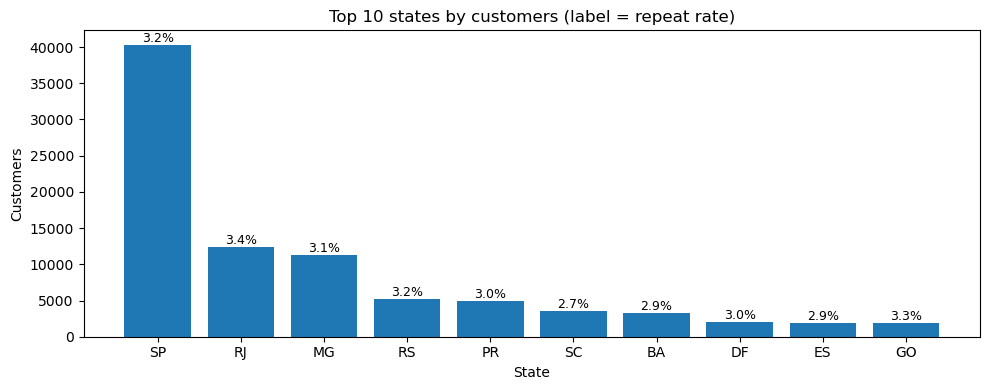

In [8]:
top_states = geo.head(10)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(top_states["state"], top_states["customers"])
for b, rr in zip(bars, top_states["repeat_rate_pct"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f"{rr:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_title("Top 10 states by customers (label = repeat rate)")
ax.set_xlabel("State")
ax.set_ylabel("Customers")
plt.tight_layout()
plt.savefig("../reports/segment_by_state.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Does what customers first buy predict whether they return?

This is the most useful cut. We label each customer by the **product category of their first order**, then
measure the repeat rate within each category. If some categories bring people back far more than others,
that's a lever: acquire more of those, or nudge the low-retention categories harder.

(We only keep categories with enough customers to be trustworthy.)

In [11]:
cat = con.execute('''
    WITH cust_orders AS (
        SELECT c.customer_unique_id, o.order_id, o.order_purchase_timestamp AS ts
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_purchase_timestamp IS NOT NULL
    ),
    order_counts AS (
        SELECT customer_unique_id, COUNT(*) AS n_orders
        FROM cust_orders GROUP BY customer_unique_id
    ),
    first_order AS (
        SELECT customer_unique_id, order_id,
               ROW_NUMBER() OVER (PARTITION BY customer_unique_id ORDER BY ts) AS rn
        FROM cust_orders
    ),
    first_item AS (
        SELECT fo.customer_unique_id, i.product_id,
               ROW_NUMBER() OVER (PARTITION BY fo.customer_unique_id
                                  ORDER BY i.order_item_id) AS irn
        FROM first_order fo
        JOIN items i ON fo.order_id = i.order_id
        WHERE fo.rn = 1
    ),
    first_cat AS (
        SELECT fi.customer_unique_id,
               COALESCE(t.product_category_name_english, 'unknown') AS category
        FROM first_item fi
        JOIN products p ON fi.product_id = p.product_id
        LEFT JOIN category_translation t
               ON p.product_category_name = t.product_category_name
        WHERE fi.irn = 1
    )
    SELECT
        fc.category,
        COUNT(*)                                                        AS customers,
        ROUND(100.0 * SUM(CASE WHEN oc.n_orders > 1 THEN 1 ELSE 0 END)
              / COUNT(*), 2)                                            AS repeat_rate_pct
    FROM first_cat fc
    JOIN order_counts oc ON fc.customer_unique_id = oc.customer_unique_id
    GROUP BY fc.category
    HAVING COUNT(*) >= 300
    ORDER BY repeat_rate_pct DESC
''').df()
cat

,category,customers,repeat_rate_pct
0,home_appliances,690,9.28
1,fashion_bags_accessories,1730,5.95
2,home_confort,363,4.68
3,furniture_decor,6057,4.62
4,bed_bath_table,8855,4.47
5,furniture_living_room,396,4.04
6,sports_leisure,7366,3.95
7,garden_tools,3396,3.06
8,unknown,1394,3.01
9,computers_accessories,6434,2.97


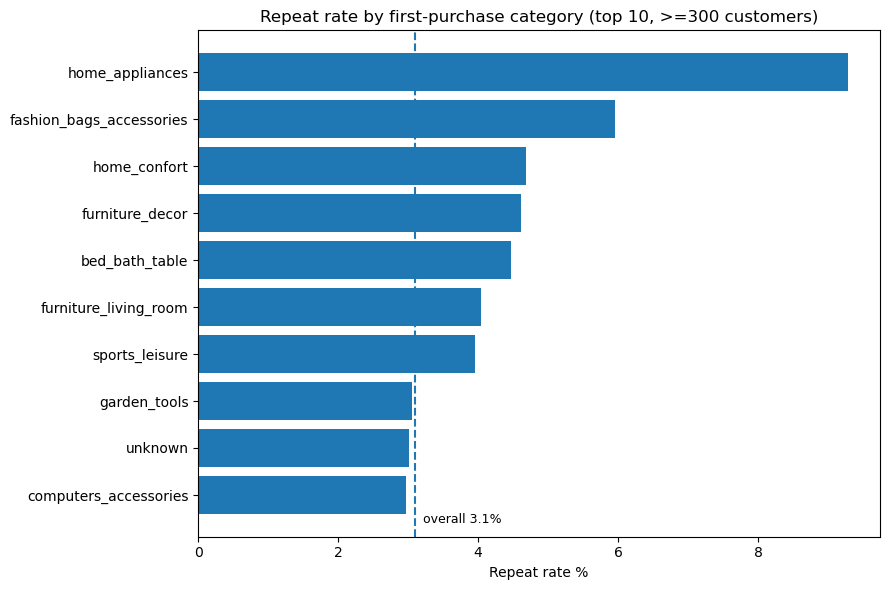

In [13]:
# Highest- and lowest-retention categories, side by side.
top_cat = cat.head(10).iloc[::-1]      # reverse for nicer bar order
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_cat["category"], top_cat["repeat_rate_pct"])
overall = 3.1
ax.axvline(overall, linestyle="--")
ax.text(overall, -0.6, f"  overall {overall}%", fontsize=9)
ax.set_title("Repeat rate by first-purchase category (top 10, >=300 customers)")
ax.set_xlabel("Repeat rate %")
plt.tight_layout()
plt.savefig("../reports/segment_by_category.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Does payment method relate to retention?

Grouping customers by the payment type of their first order. Sometimes payment behavior (e.g. installments
vs. one-off) correlates with commitment or customer type.

In [16]:
pay = con.execute('''
    WITH cust_orders AS (
        SELECT c.customer_unique_id, o.order_id, o.order_purchase_timestamp AS ts
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_purchase_timestamp IS NOT NULL
    ),
    order_counts AS (
        SELECT customer_unique_id, COUNT(*) AS n_orders
        FROM cust_orders GROUP BY customer_unique_id
    ),
    first_order AS (
        SELECT customer_unique_id, order_id,
               ROW_NUMBER() OVER (PARTITION BY customer_unique_id ORDER BY ts) AS rn
        FROM cust_orders
    ),
    first_pay AS (
        SELECT fo.customer_unique_id, ANY_VALUE(p.payment_type) AS payment_type
        FROM first_order fo
        JOIN payments p ON fo.order_id = p.order_id
        WHERE fo.rn = 1
        GROUP BY fo.customer_unique_id
    )
    SELECT
        fp.payment_type,
        COUNT(*)                                                        AS customers,
        ROUND(100.0 * SUM(CASE WHEN oc.n_orders > 1 THEN 1 ELSE 0 END)
              / COUNT(*), 2)                                            AS repeat_rate_pct
    FROM first_pay fp
    JOIN order_counts oc ON fp.customer_unique_id = oc.customer_unique_id
    GROUP BY fp.payment_type
    ORDER BY customers DESC
''').df()
pay

,payment_type,customers,repeat_rate_pct
0,credit_card,72871,3.12
1,boleto,19190,3.07
2,voucher,2549,3.96
3,debit_card,1483,2.36
4,not_defined,2,0.00


## 5. Customer value — where does revenue concentrate?

Even in a low-retention business, revenue is rarely spread evenly. We compute total spend per customer and
ask: what share of revenue comes from the top slice of customers? A steep concentration means a small,
targetable group is worth disproportionately more — exactly who a retention program should protect.

In [19]:
value = con.execute('''
    SELECT
        c.customer_unique_id,
        SUM(p.payment_value) AS total_spend
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN payments p  ON o.order_id   = p.order_id
    WHERE o.order_purchase_timestamp IS NOT NULL
    GROUP BY c.customer_unique_id
''').df()

print(f"Customers with spend data: {len(value):,}")
value["total_spend"].describe().round(2)

Customers with spend data: 96,095


count    96095.00
mean       166.59
std        231.43
min          0.00
25%         63.12
50%        108.00
75%        183.53
max      13664.08
Name: total_spend, dtype: float64

Top  5% of customers  ->  27.0% of revenue
Top 10% of customers  ->  38.5% of revenue
Top 20% of customers  ->  53.8% of revenue


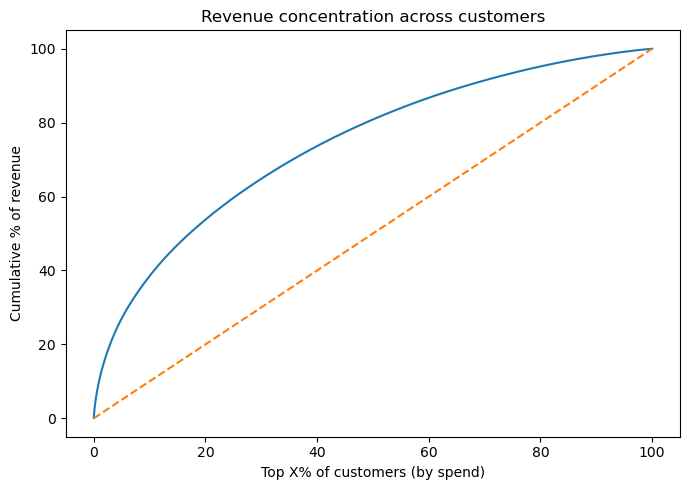

In [21]:
# Revenue concentration (a Lorenz-style curve).
v = value["total_spend"].sort_values(ascending=False).reset_index(drop=True)
n = len(v)
cum_share = v.cumsum() / v.sum()

for pct in (0.05, 0.10, 0.20):
    idx = max(int(n * pct) - 1, 0)
    print(f"Top {int(pct*100):>2}% of customers  ->  {cum_share.iloc[idx]:.1%} of revenue")

cust_pctile = (pd.Series(range(1, n + 1)) / n) * 100
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(cust_pctile, cum_share * 100)
ax.plot([0, 100], [0, 100], linestyle="--")   # line of perfect equality
ax.set_title("Revenue concentration across customers")
ax.set_xlabel("Top X% of customers (by spend)")
ax.set_ylabel("Cumulative % of revenue")
plt.tight_layout()
plt.savefig("../reports/revenue_concentration.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. What did we find? 

Retention is low everywhere; SP, RJ, and MG hold most customers, but all repeat at roughly 3%, confirming the problem is structural, not regional. First-purchase category, however, matters a lot: customers whose first order was in home_appliances return at ~7% and fashion_bags_accessories at ~5%, versus the 3.1% baseline, while categories like computers_accessories barely retain anyone. The payment method shows little difference (credit card, the dominant method, sits near the 3.3% average). Revenue is concentrated: the top 10% of customers drive 38.5% of revenue.
